In [1]:
!nvidia-smi

Mon Mar 30 07:16:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%%capture
!pip install ultralytics
!pip install roboflow

In [3]:
from roboflow import Roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6842.1/8062.4 GB disk)


In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="9VCfGRMmzvi61B4c9qu5")
project = rf.workspace("agabaembedded").project("ship-detection-sar-full")
version = project.version(1)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Ship-Detection-SAR-Full-1 in yolo26:: 100%|██████████| 18152/18152 [00:02<00:00, 6821.46it/s] 


In [5]:
!yolo train \
model= yolo26m.pt \
data=/kaggle/working/Ship-Detection-SAR-Full-1/data.yaml \
epochs=300 \
imgsz=640 \
device=[0, 1] \
plots=True \
pretrained = False\
save = True \
deterministic=False \
optimizer = SGD \
cos_lr=True \
time = 11 \
lr0=0.00683 \
lrf=0.00933 \
momentum=0.88752 \
weight_decay=0.00049 \
warmup_epochs=4.35648 \
warmup_momentum=0.55489 \
box=6.78881 \
cls=0.83514 \
dfl=1.20718 \
hsv_h=0.01201 \
hsv_s=0.50385 \
hsv_v=0.46926 \
degrees=0.0 \
translate=0.08133 \
scale=0.41964 \
shear=0.0 \
perspective=0.0 \
flipud=0.0 \
fliplr=0.4635 \
bgr=0.0 \
mosaic=0.5579 \
mixup=0.0 \
cutmix=0.0 \
copy_paste=0.0

Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=6.78881, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.83514, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/Ship-Detection-SAR-Full-1/data.yaml, degrees=0.0, deterministic=False, device=0,1, dfl=1.20718, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.4635, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01201, hsv_s=0.50385, hsv_v=0.46926, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00683, lrf=0.00933, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.88752, mosaic=0.5

In [6]:
!yolo export model=/kaggle/working/yolo11n.pt format=torchscript

Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

PyTorch: starting from '/kaggle/working/yolo11n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (5.4 MB)

TorchScript: starting export with torch 2.10.0+cu128...
TorchScript: export success ✅ 2.2s, saved as '/kaggle/working/yolo11n.torchscript' (10.5 MB)

Export complete (2.7s)
Results saved to /kaggle/working
Predict:         yolo predict task=detect model=/kaggle/working/yolo11n.torchscript imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/yolo11n.torchscript imgsz=640 data=/usr/src/ultralytics/ultralytics/cfg/datasets/coco.yaml  
Visualize:       https://netron.app
💡 Learn more at https://docs.ultralytics.com/modes/export


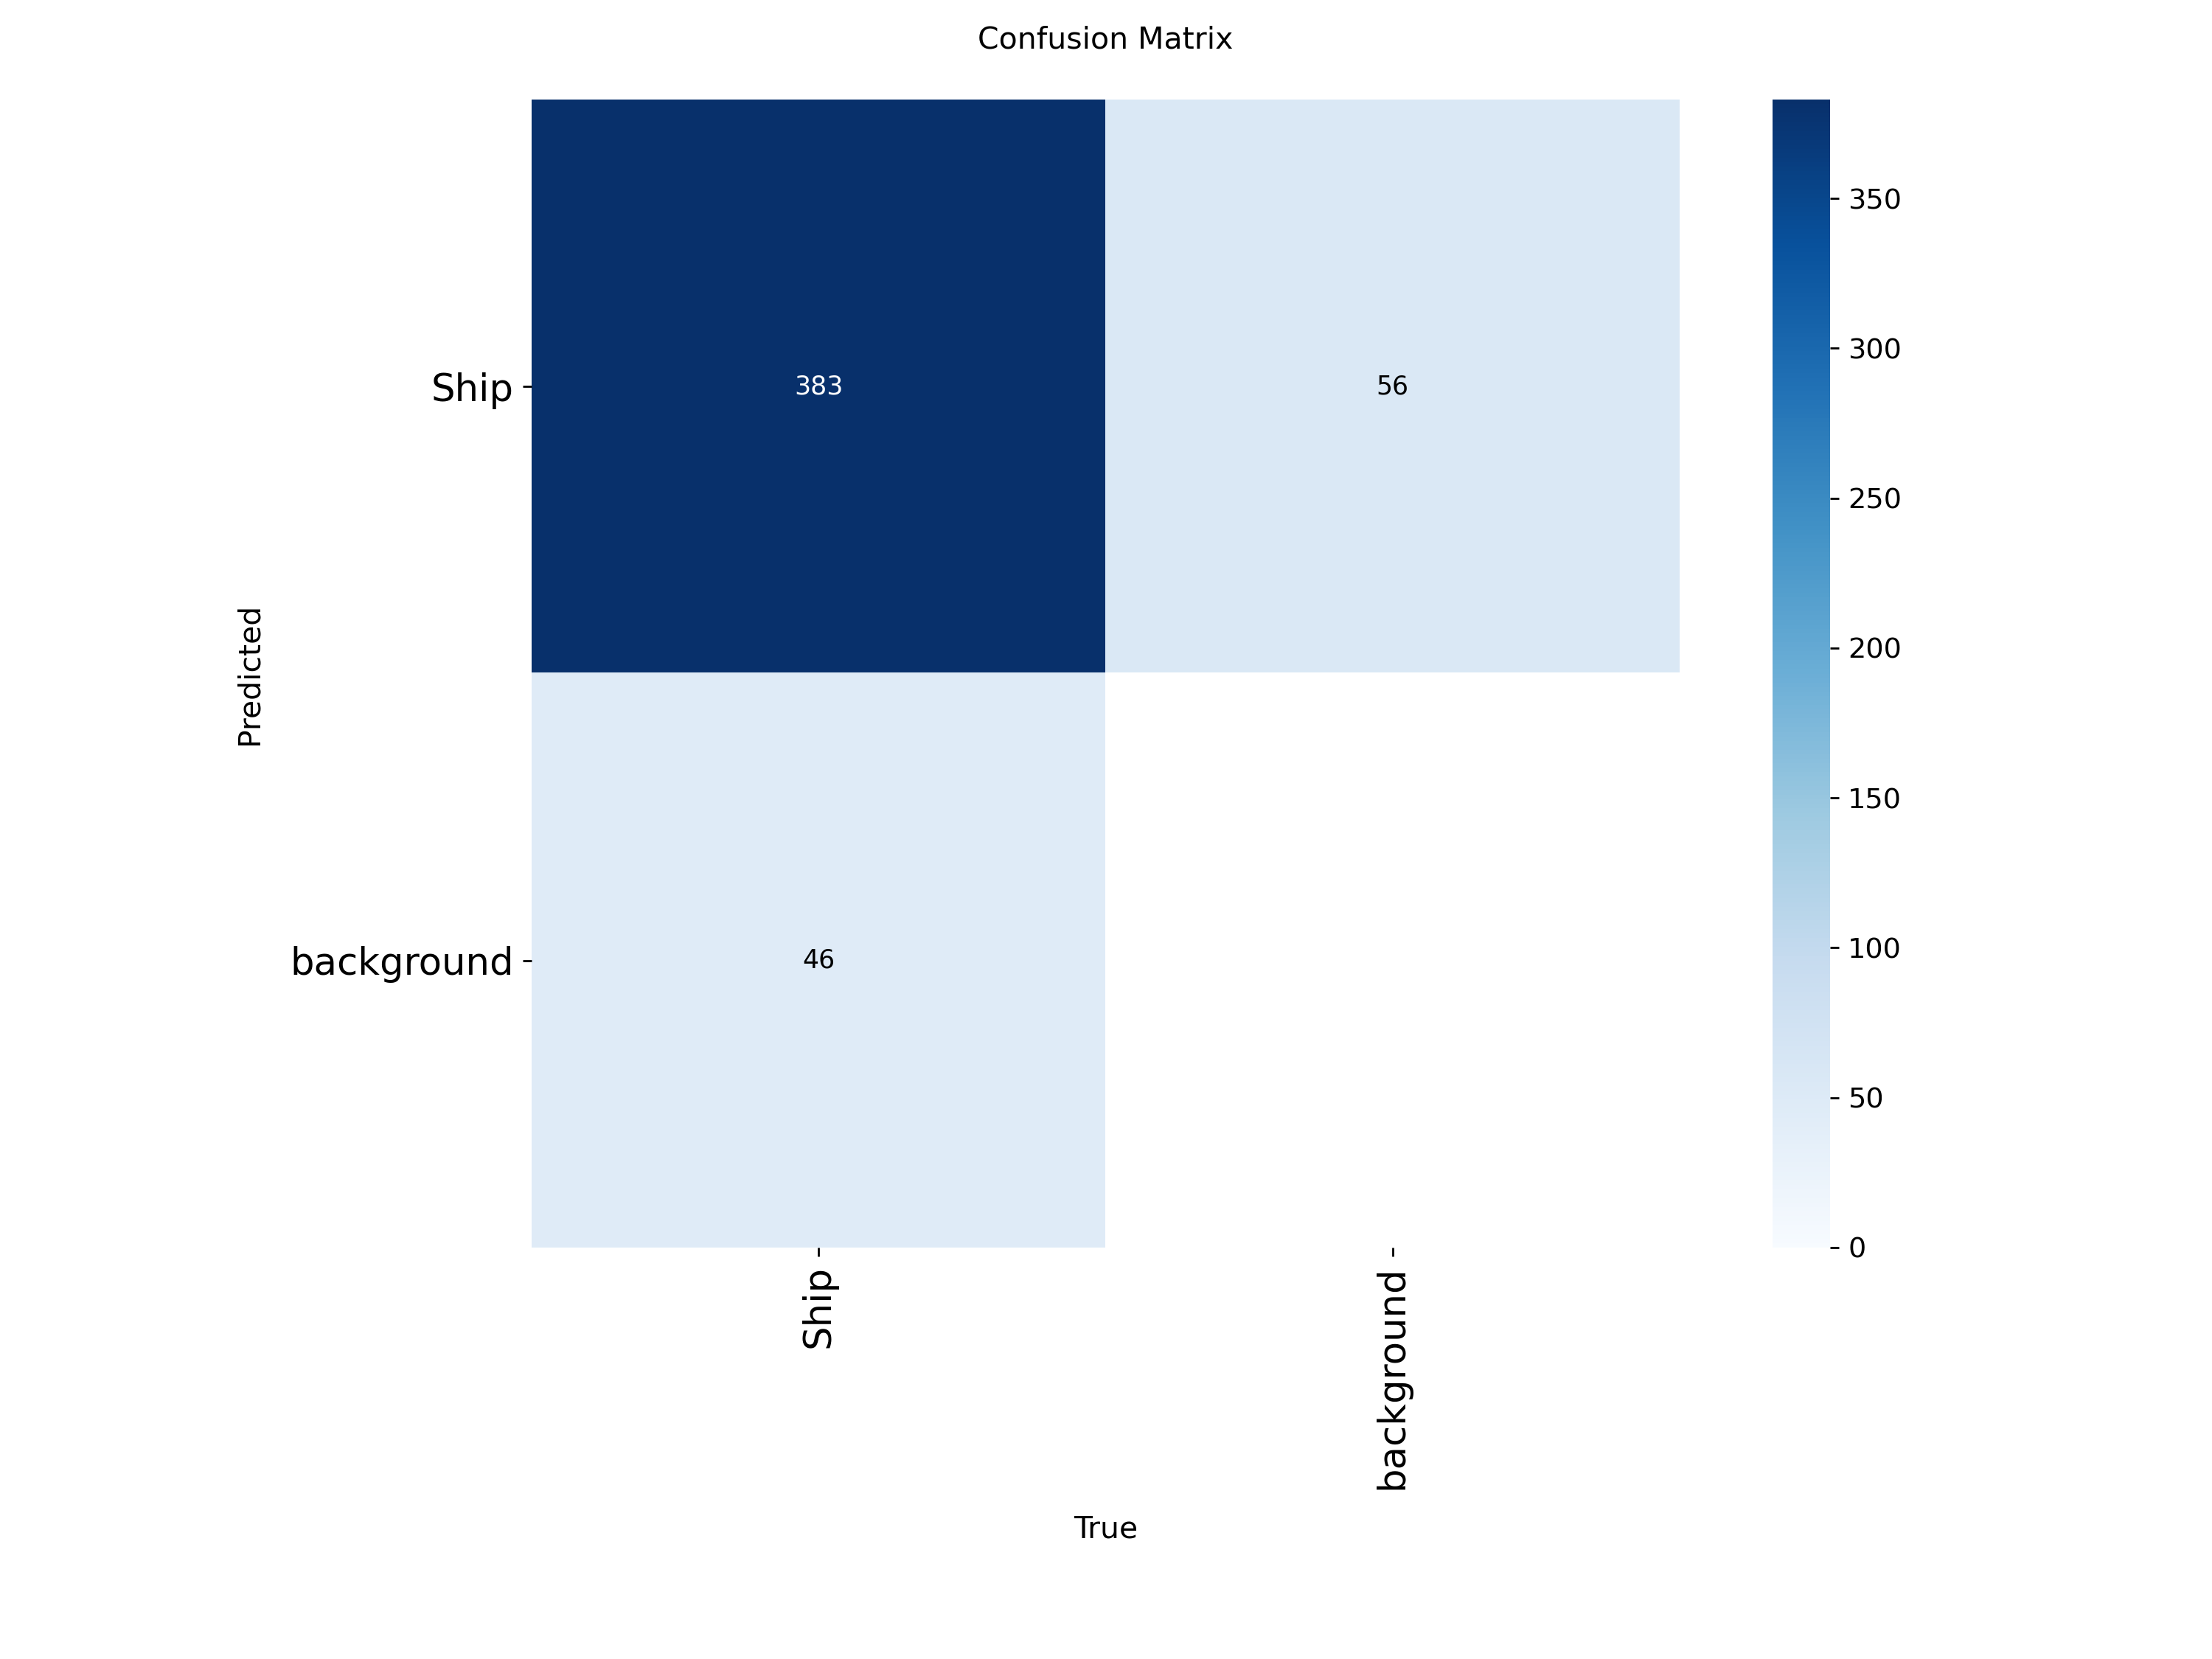

In [7]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'/kaggle/working/runs/detect/train/confusion_matrix.png', width=600)

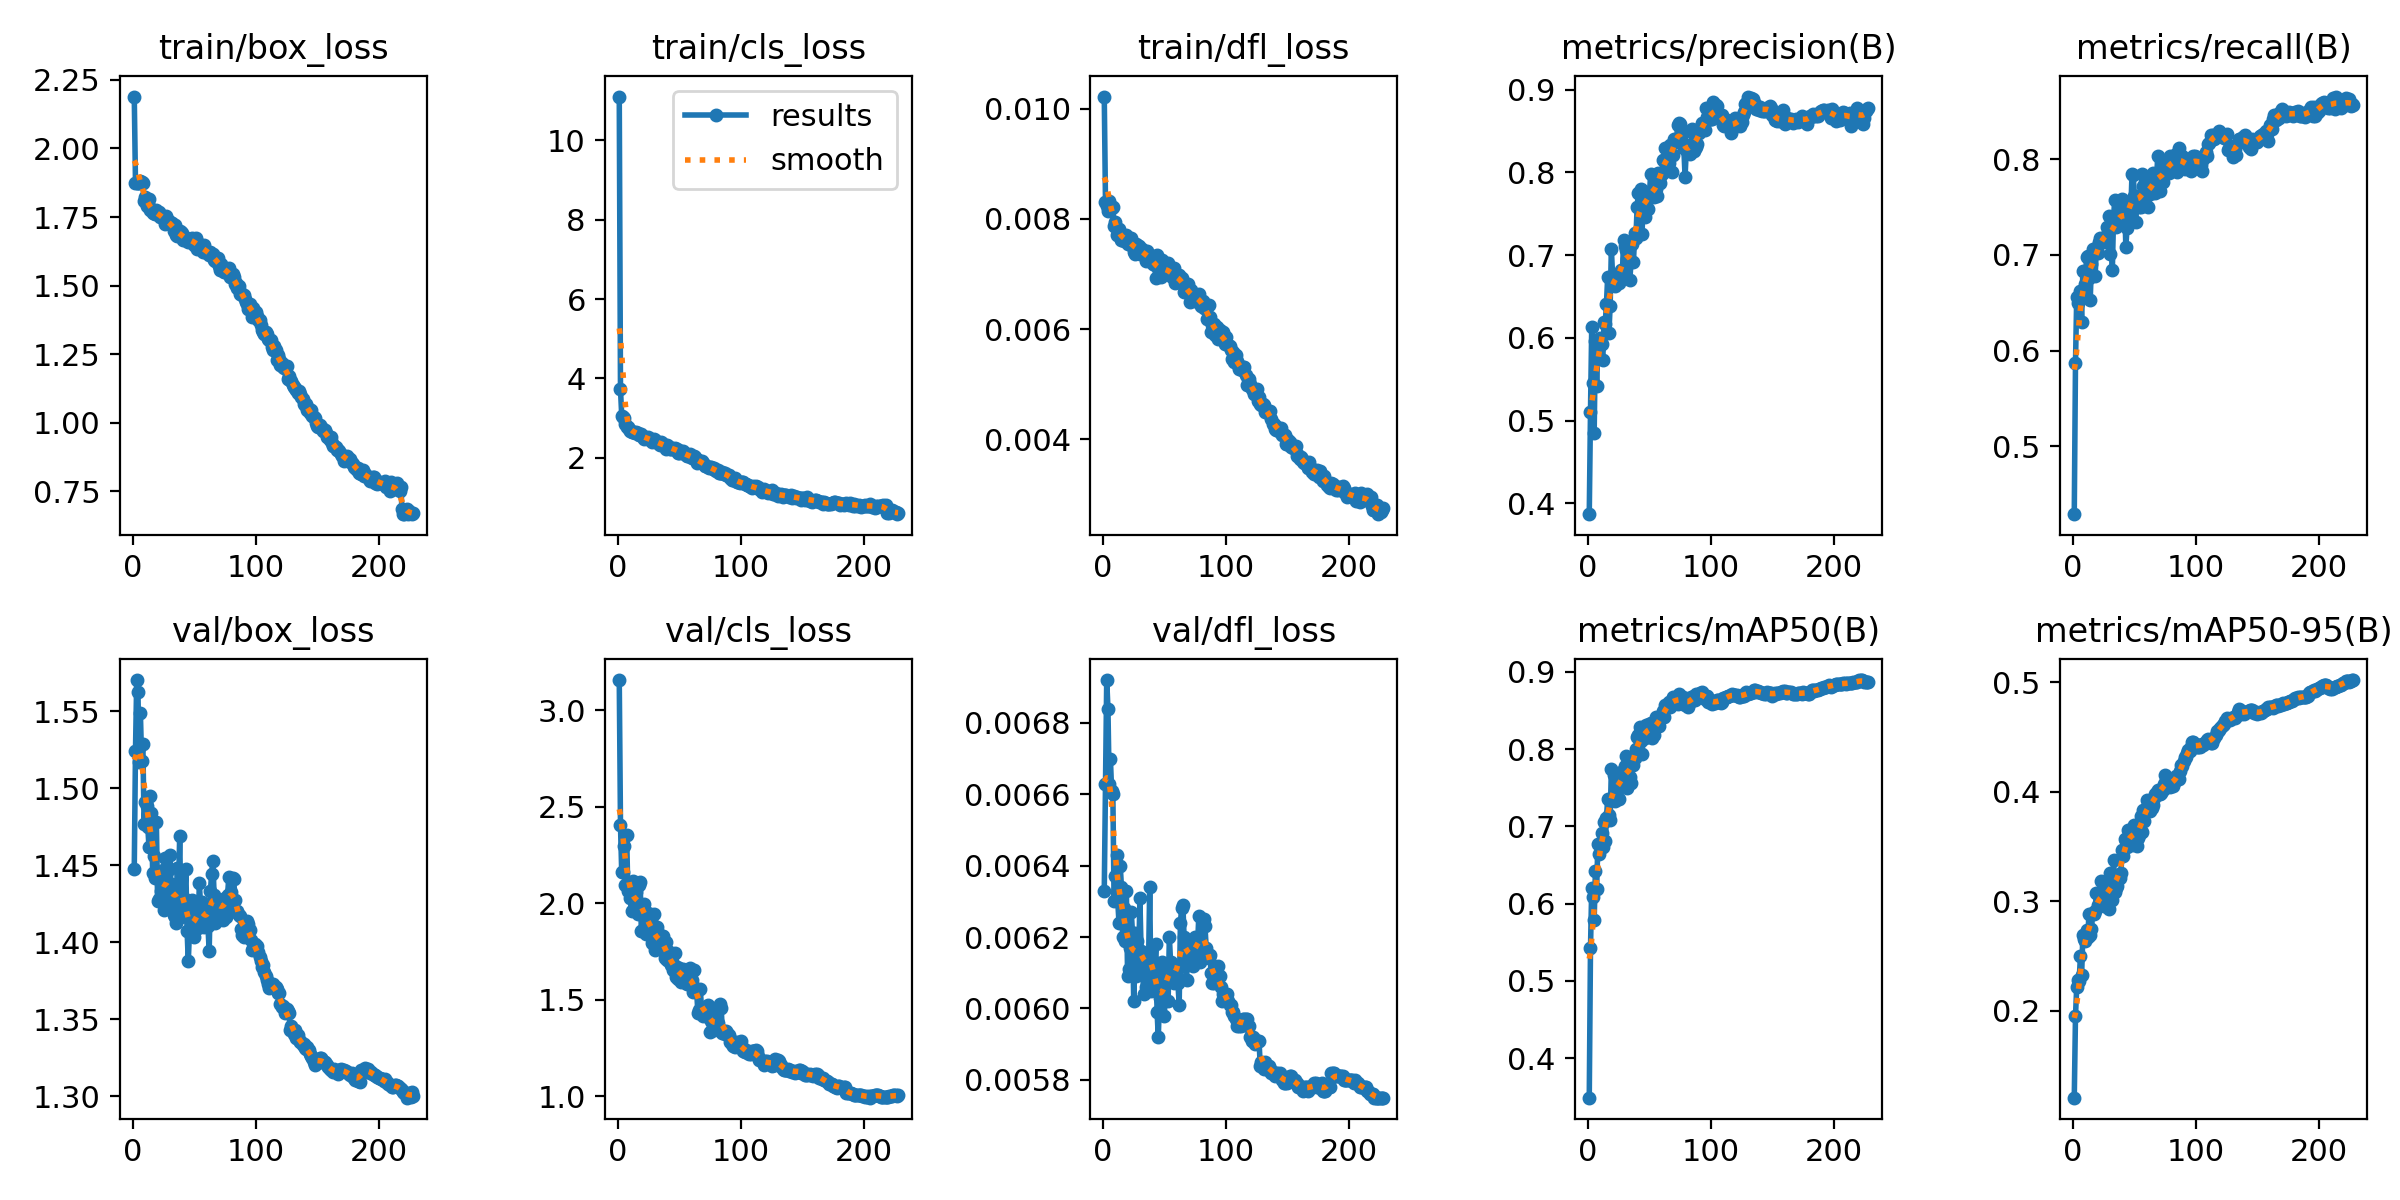

In [8]:
IPyImage(filename=f'/kaggle/working/runs/detect/train/results.png', width=600)

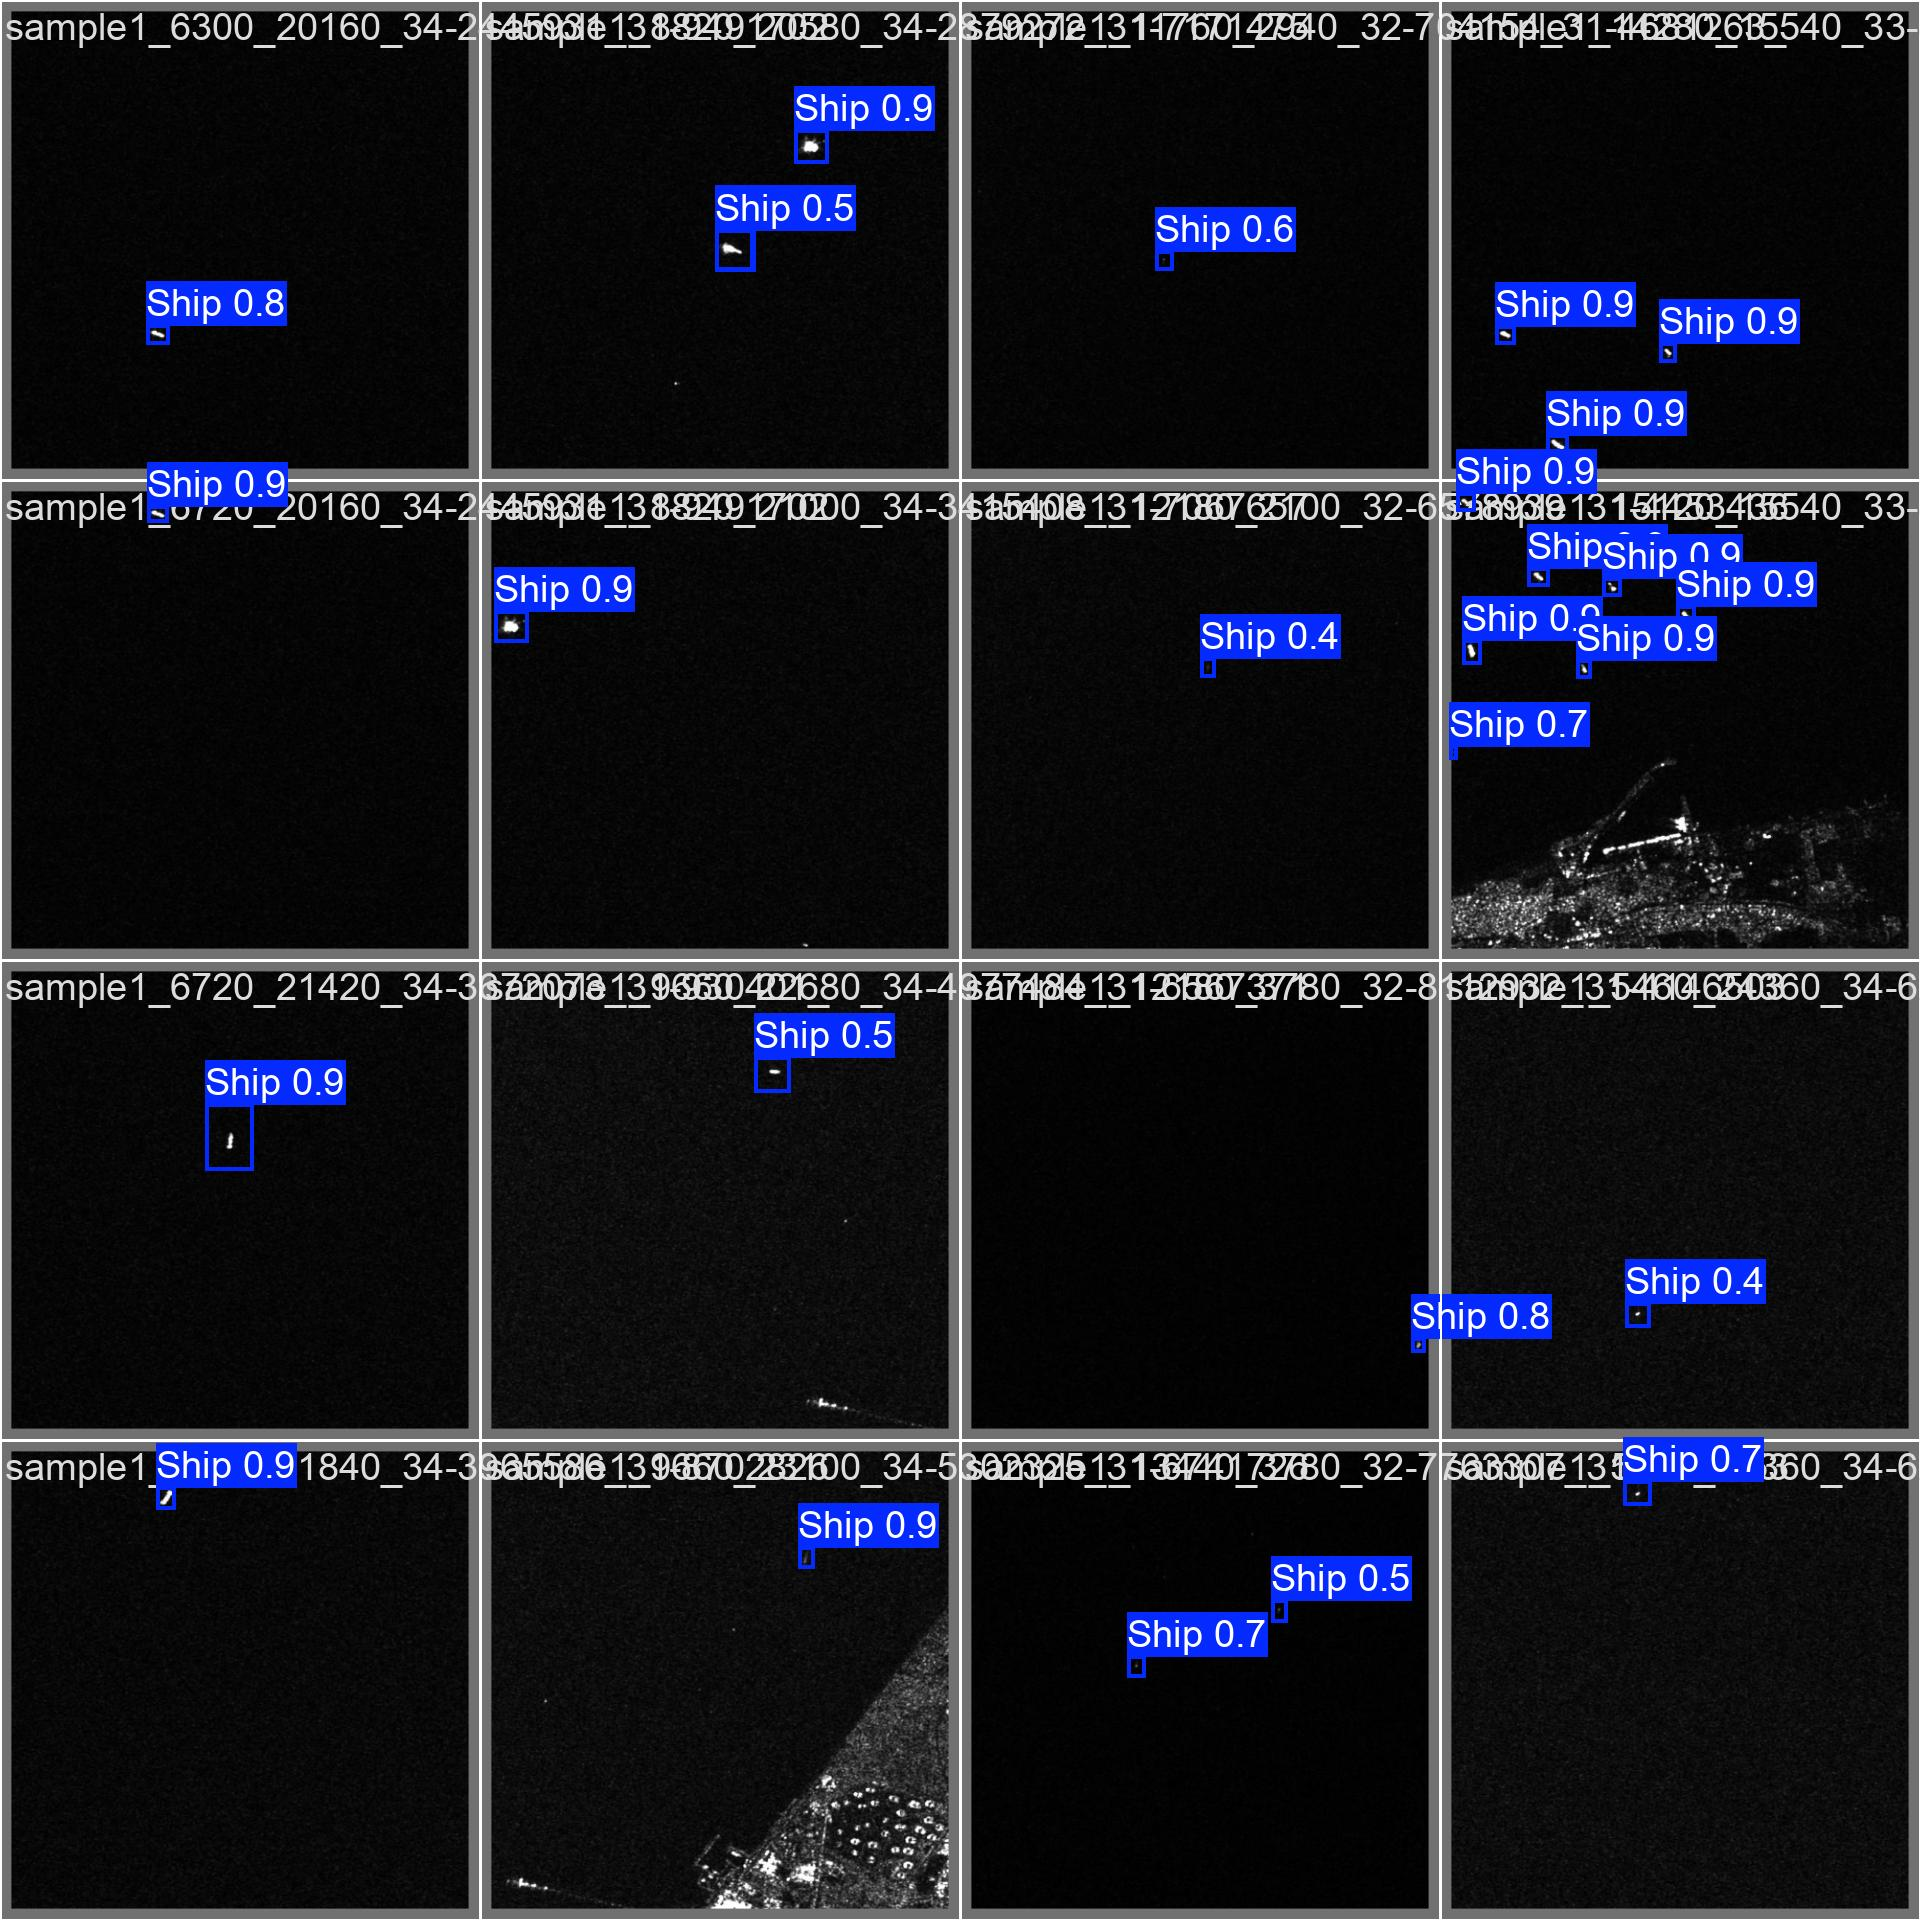

In [9]:
IPyImage(filename=f'/kaggle/working/runs/detect/train/val_batch0_pred.jpg', width=600)